## NBA Player Minutes Predictor - XGBoost Quantile
**- Owner:** Alex

**- Status:** Exploration only - not a production pipeline yet

**- Last Updated:** 9/28/26

### Question

**How accurately can we predict an NBA player's minutes in their next game,
and can XGBoost beat last-game minutes, the season-to-date average, and an EWMA of recent minutes?**

### Decision Criteria
**- Primary metric:** q50 pinball (minutes). Lower is better.

**- Secondary metric:** 80% interval (q10–q90) and 90% interval (q05–q95) coverage near their targets

**- Serving threshold:** none yet — exploration only

**- Guardrail:** no quantile crossing; 2025-26 is scored once and never used to tune

### Data Contract
**- Data:** nba_api, rotowire, and basketball reference

**- Unit:** one row per player-game (`game_id`, `player_id`)

**- Features:** known 1 hour before tip-off (prior minutes, role, schedule, market)

**- Label:** minutes played (`minutes` > 0)

**- Split:** chronological; train on 2023-24 and 2024-25, hold out 2025-26


### Setup and Configurations

In [42]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

def _repo_root() -> Path:
    starts = []
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        starts.append(Path(nb).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / "pyproject.toml").is_file():
                return candidate
    raise RuntimeError("could not find repo root (pyproject.toml)")

ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.minutes import (
    TIER1_MINUTES_FEATURES,
    add_minutes_features,
)

In [43]:
# ── Prop-specific config (NBA MIN) ────────────────────────────────────────────

HOLDOUT_SEASON = "2025-26"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
TARGET_COL = "minutes"
ROLE_COL = "starting"
SEED = 42

QUANTILES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

XGB_PARAMS = dict(
    objective="reg:quantileerror",
    n_estimators=1198,
    max_depth=4,
    learning_rate=0.10831429032170246,
    subsample=0.7978199709619458,
    colsample_bytree=0.8074992328271139,
    reg_alpha=4.019094324629617,
    reg_lambda=0.7852113626147341,
    min_child_weight=8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
    seed=SEED
)
MIN_TIERS = {
    "<15 min": lambda a: a < 15,
    "15-24 min": lambda a: (a >= 15) & (a < 24),
    "24-31 min": lambda a: (a >= 24) & (a < 31),
    "31+ min": lambda a: a >= 31,
}

ARTIFACT_STEM = "min_nba_model"

# ── Shared train/eval helpers ─────────────────────────────────────────────────
from models.shared.splits import prepare_splits
from models.shared.train import (
    evaluate_holdout,
    run_timeseries_cv,
    run_walk_forward,
)
from models.shared.analysis import run_feature_ablation, analyze_correlations
from models.shared.artifacts import save_model_bundle, load_model_bundle, predict_quantiles
from models.shared.metrics import interval_coverage, pinball_50, pinball_loss


### Data

In [44]:
s20 = pd.read_parquet(ROOT / "data/silver/nba/2019-20/regular_season/player_gamelogs.parquet")
s21 = pd.read_parquet(ROOT / "data/silver/nba/2020-21/regular_season/player_gamelogs.parquet")
s22 = pd.read_parquet(ROOT / "data/silver/nba/2021-22/regular_season/player_gamelogs.parquet")
s23 = pd.read_parquet(ROOT / "data/silver/nba/2022-23/regular_season/player_gamelogs.parquet")
s24 = pd.read_parquet(ROOT / "data/silver/nba/2023-24/regular_season/player_gamelogs.parquet")
s25 = pd.read_parquet(ROOT / "data/silver/nba/2024-25/regular_season/player_gamelogs.parquet")
s26 = pd.read_parquet(ROOT / "data/silver/nba/2025-26/regular_season/player_gamelogs.parquet")
df = pd.concat([s20, s21, s22, s23, s24, s25, s26])
df['starting'] = (
    df['start_position'].astype('string').str.strip().isin(['G', 'F', 'C']).astype(int)
)
df.sample(5)

,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,...,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread,starting
15401,2019-20,202710,Jimmy Butler III,Jimmy,1610612748,MIA,Miami Heat,0021900324,2019-12-06T00:00:00,MIA vs. WAS,...,96.0,80.00,96,0.436,Regular Season,SF,228.5,-9.5,-9.5,1
9001,2020-21,1627936,Alex Caruso,Alex,1610612747,LAL,Los Angeles Lakers,0022000693,2021-03-26T00:00:00,LAL vs. CLE,...,102.0,85.00,101,0.396,Regular Season,PG,206.5,-4.0,-4.0,0
23620,2022-23,1631216,Caleb Houstan,Caleb,1610612753,ORL,Orlando Magic,0022200105,2022-11-01T00:00:00,ORL @ OKC,...,107.5,89.58,107,0.524,Regular Season,SF,216.0,-3.0,3.0,0
7452,2019-20,1629645,Kevin Porter Jr.,Kevin,1610612739,CLE,Cleveland Cavaliers,0021900700,2020-01-28T00:00:00,CLE vs. NOP,...,102.0,85.00,102,0.576,Regular Season,SF,232.0,8.5,8.5,0
9313,2023-24,1629638,Nickeil Alexander-Walker,Nickeil,1610612750,MIN,Minnesota Timberwolves,0022300770,2024-02-12T00:00:00,MIN @ LAC,...,95.5,79.58,96,0.378,Regular Season,SG,224.0,-5.0,5.0,0


In [45]:
# Data Quality Checks
print(f"Number of rows : {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Number of Unique Players: {df['player_id'].nunique()}")
print(f"Number of Unique Games: {df['game_id'].nunique()}")
print(f"Total number of duplicates: {df.duplicated(subset=['game_id', 'player_id']).sum()}")
print(f"Missing Labels: {df['minutes'].isna().sum()}")
print(f"Missing Start Position: {df['starting'].isna().sum()}")
print(f"Median Minutes: {df['minutes'].median()}")
print(f"Mean Minutes: {df['minutes'].mean().round(3)}")
print(f"Max Minutes: {df['minutes'].max().round(3)}")
print(f"Standard Deviation of Minutes: {df['minutes'].std().round(3)}")
print(f"Skewness of Minutes: {df['minutes'].skew().round(3)}")
print(f"Kurtosis of Minutes: {df['minutes'].kurt().round(3)}")
avg_min = df.groupby('player_id')['minutes'].mean()
for t in [10, 20, 30, 35]:
    pct = (avg_min >= t).mean() * 100
    print(f"Percentage of players averaging {t}+ minutes: {pct:.1f}%")

Number of rows : 176738
Number of columns: 190
Number of Unique Players: 1172
Number of Unique Games: 8289
Total number of duplicates: 0
Missing Labels: 0
Missing Start Position: 0
Median Minutes: 23.64
Mean Minutes: 22.65
Max Minutes: 56.517
Standard Deviation of Minutes: 10.67
Skewness of Minutes: -0.279
Kurtosis of Minutes: -0.805
Percentage of players averaging 10+ minutes: 75.1%
Percentage of players averaging 20+ minutes: 34.9%
Percentage of players averaging 30+ minutes: 8.4%
Percentage of players averaging 35+ minutes: 0.9%


### Features

In [ ]:
# adds features to the dataset
from src.features.minutes import add_starter_features

df = add_starter_features(df)
df = add_minutes_features(df)

In [ ]:
# Top 3 are starter_rank 1-3: most prior starts, then prior minutes.
# total_stars_active is how many of those three played (minutes > 0).
stars = df["starter_rank"].le(3)
played = df["minutes"].fillna(0).gt(0)
active = (
    df.loc[stars, ["team_id", "game_id"]]
    .assign(played=played.loc[stars].astype(int))
    .groupby(["team_id", "game_id"], sort=False)["played"]
    .sum()
)
df["total_stars_active"] = (
    df.set_index(["team_id", "game_id"]).index.map(active).fillna(0).astype(int)
)
print(df["total_stars_active"].value_counts().sort_index())


In [ ]:
# selected features to use in the model
MIN_FEATURES = [
    # role / starter status
    "starting",
    "starter_rank",
    "start_rate_10",
    "season_start_rate",
    "start_rate_x_abs_spread",
    "starter_min_missing_teammates",
    "total_stars_active", #new

    # recent minutes level
    "min_avg_lN",
    "min_lag_1",
    "min_ewm_hl_10",

    # availability / workload
    "player_days_since_appearance",
    "player_appearances_prev_7d",

    # game context
    "implied_team_total",

    # spread of minutes (mainly for interval width)
    "min_p80_20",
    "min_p80_minus_p20_20",
]
 
print(f"Number of features: {len(MIN_FEATURES)}")
print(f"Number of nulls: {df[MIN_FEATURES].isna().sum().sum()}")

Number of features: 14
Number of nulls: 41026


### Train/validation/test design
**- Train:** 2019-10-22 → 2025-04-13 (2019-20, 2020-21, 2021-22, 2022-23, 2023-24, 2024-25). Each fold fits on its past dates. The 2025-26 fit uses the first 90% of this pool.

**- Validation:** Inside the train pool only. Optuna picks hyperparameters on a 3-fold TimeSeriesSplit by q50 pinball. Walk-forward then scores 4 non-overlapping blocks, each the next 10% of game dates after a 50% training window, stepping forward 10%. Those windows end 2024-11-25, 2024-12-31, 2025-02-01, and 2025-03-10. The first half of train dates, and dates after 2025-03-10, are never scored.

**- Test:** 2025-10-21 → 2026-04-12 (2025-26). Scored once, after features and hyperparameters are locked on the validation folds.

**- Split type:** Chronological. Walk-forward keeps every row from a game_date on one side. TimeSeriesSplit cuts by row index, so one slate can straddle a fold.

**- Embargo:** None. The next game date after the last training date is validation. The gap from 2025-04-13 to 2025-10-21 is the offseason, not a purge.

**- Important:** 2025-26 is not used to choose features, hyperparameters, or early-stopping rounds. Walk-forward still early-stops on the rows it scores. The holdout fit early-stops on the last 10% of the train pool and never puts 2025-26 in eval_set.

In [ ]:
df = df[(df['minutes'] > 0)]
print(f"After filtering minutes: {df[MIN_FEATURES].shape[0]} rows")

splits = prepare_splits(
    df,
    holdout_season=HOLDOUT_SEASON,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    id_cols=ID_COLS,
    role_col=ROLE_COL,
    extra_keep=["minutes", "pts", "min_ewm_hl_10"],
)
ppm_df = splits["ppm_df"]
ppm_holdout = splits["ppm_holdout"]
X = splits["X"]
y = splits["y"]

After filtering minutes: 176710 rows
Train pool (excl. 2025-26) : 150,062 rows
Holdout   (2025-26)        : 26,648 rows
Date range (train)   : 2019-10-22 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12


### EDA

Appearance rows: 176,710
Features with a null: 11 / 14
Rows with any null feature: 14,573 (8.2%)


,n_missing,pct_missing
min_avg_lN,5947,3.37
min_p80_20,5629,3.19
min_p80_minus_p20_20,5629,3.19
start_rate_x_abs_spread,5351,3.03
implied_team_total,4706,2.66
player_days_since_appearance,3936,2.23
season_start_rate,3934,2.23
starter_min_missing_teammates,2360,1.34
start_rate_10,1172,0.66
min_lag_1,1172,0.66


,min_avg_lN,min_p80_20,min_p80_minus_p20_20,start_rate_x_abs_spread,implied_team_total,player_days_since_appearance,season_start_rate,starter_min_missing_teammates,start_rate_10,min_lag_1,min_ewm_hl_10
season_year,,,,,,,,,,,
2019-20,3.5,11.5,11.5,10.0,7.7,2.4,2.4,1.4,2.4,2.4,2.4
2020-21,3.4,2.3,2.3,0.5,0.0,2.3,2.3,1.4,0.5,0.5,0.5
2021-22,3.5,2.3,2.3,2.8,4.1,2.3,2.3,1.3,0.5,0.5,0.5
2022-23,3.2,1.6,1.6,1.0,0.7,2.1,2.1,1.3,0.3,0.3,0.3
2023-24,3.4,1.8,1.8,4.3,3.9,2.2,2.2,1.3,0.4,0.4,0.4
2024-25,3.4,2.0,2.0,0.6,0.2,2.2,2.2,1.4,0.4,0.4,0.4
2025-26,3.3,1.9,1.9,2.7,2.4,2.2,2.2,1.3,0.4,0.4,0.4


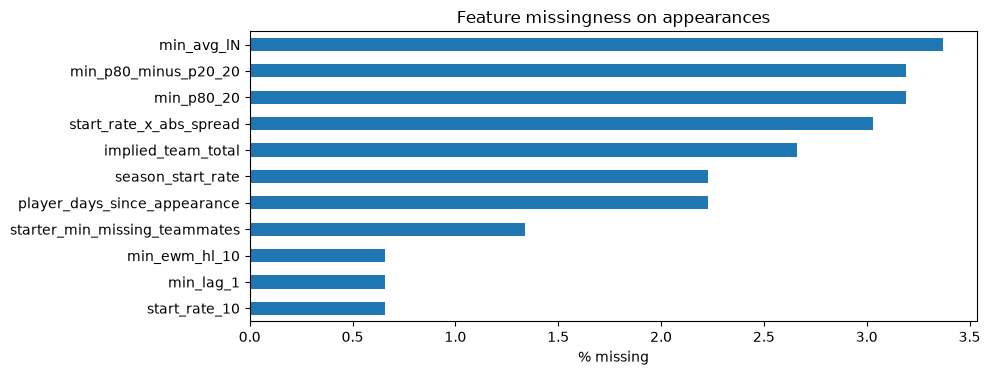

In [ ]:
# Feature missingness

miss = pd.DataFrame({
    "n_missing": df[MIN_FEATURES].isna().sum(),
    "pct_missing": (df[MIN_FEATURES].isna().mean() * 100).round(2),
}).sort_values(["pct_missing", "n_missing"], ascending=False)

n_any = int(df[MIN_FEATURES].isna().any(axis=1).sum())
print(f"Appearance rows: {len(df):,}")
print(f"Features with a null: {int((miss['n_missing'] > 0).sum())} / {len(MIN_FEATURES)}")
print(f"Rows with any null feature: {n_any:,} ({n_any / len(df):.1%})")

sparse = miss.index[miss["n_missing"] > 0].tolist()
display(miss)
if sparse:
    season_miss_pct = (
        df[sparse]
        .isna()
        .groupby(df["season_year"], sort=True)
        .mean()
        .mul(100)
        .round(1)
    )
    display(season_miss_pct)
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(sparse))))
    miss.loc[sparse, "pct_missing"].sort_values().plot.barh(ax=ax, color="C0")
    ax.set_xlabel("% missing")
    ax.set_title("Feature missingness on appearances")
    fig.tight_layout()
    plt.show()
else:
    print("Every selected feature is complete on this frame.")


n=176,710  min=0.02  p50=23.65  max=56.52
Tukey fence [-9.27, 55.59]  outside=4 (0.0%)
Player minutes above 48 (overtime range): 81


,season_year,game_date,player_name,minutes,starting
62209,2021-22,2022-01-29,Pascal Siakam,56.516667,1
141903,2021-22,2022-01-29,Scottie Barnes,56.333333,1
71545,2021-22,2022-01-29,OG Anunoby,55.816667,1
92124,2021-22,2022-01-29,Gary Trent Jr.,55.650000,1
126602,2022-23,2023-03-05,Immanuel Quickley,55.100000,1
123639,2023-24,2024-04-07,Tyrese Maxey,53.950000,1
64751,2021-22,2022-01-29,Fred VanVleet,53.516667,1
155436,2024-25,2025-04-01,Christian Braun,53.166667,1


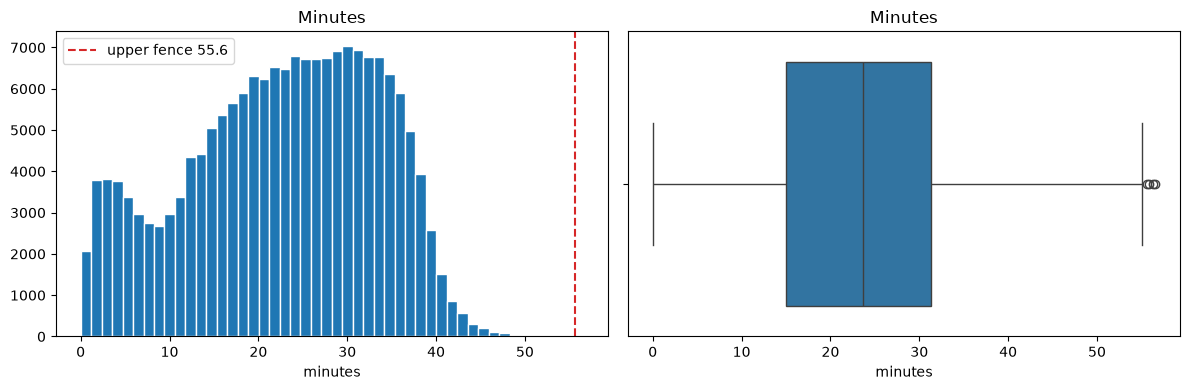

Binary inputs are omitted. A point is outside when it is past 1.5 IQR from the quartiles.


,feature,n,pct_outside,fence_low,fence_high,min,p50,max
0,player_days_since_appearance,172774,10.05,0.50,4.50,1.00,2.00,30.00
1,player_appearances_prev_7d,176710,7.79,0.50,4.50,0.00,3.00,5.00
2,start_rate_x_abs_spread,171359,4.54,-6.75,11.25,0.00,1.30,25.50
3,min_p80_minus_p20_20,171081,2.84,-0.79,18.87,0.32,8.74,34.36
4,starter_min_missing_teammates,174350,2.01,-47.19,78.66,0.00,0.00,177.64
5,implied_team_total,172004,0.28,96.62,129.62,94.75,113.00,135.25
6,min_p80_20,171081,0.01,2.21,53.84,1.32,28.73,45.72
7,starter_rank,176710,0.00,-7.50,20.50,1.00,7.00,22.00
8,start_rate_10,175538,0.00,-1.50,2.50,0.00,0.30,1.00
9,season_start_rate,172776,0.00,-1.50,2.50,0.00,0.28,1.00


In [ ]:
# Outliers

minutes = df["minutes"]
q1, q3 = minutes.quantile(0.25), minutes.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_tukey = int(((minutes < lo) | (minutes > hi)).sum())
n_ot = int((minutes > 48).sum())
print(
    f"n={len(minutes):,}  min={minutes.min():.2f}  "
    f"p50={minutes.median():.2f}  max={minutes.max():.2f}"
)
print(
    f"Tukey fence [{lo:.2f}, {hi:.2f}]  "
    f"outside={n_tukey:,} ({n_tukey / len(minutes):.1%})"
)
print(f"Player minutes above 48 (overtime range): {n_ot:,}")

top_minutes = (
    df.nlargest(8, "minutes")[
        ["season_year", "game_date", "player_name", "minutes", "starting"]
    ]
    .assign(game_date=lambda frame: pd.to_datetime(frame["game_date"]).dt.date)
)
display(top_minutes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(minutes, bins=48, color="C0", edgecolor="white")
axes[0].axvline(hi, color="C3", ls="--", label=f"upper fence {hi:.1f}")
axes[0].set_title("Minutes")
axes[0].set_xlabel("minutes")
axes[0].legend()
sns.boxplot(x=minutes, ax=axes[1], color="C0")
axes[1].set_title("Minutes")
fig.tight_layout()
plt.show()

outlier_rows = []
for col in MIN_FEATURES:
    values = df[col].dropna()
    if values.nunique(dropna=True) <= 2:
        continue
    fq1, fq3 = values.quantile([0.25, 0.75])
    spread = float(fq3 - fq1)
    if spread <= 0:
        continue
    fence_lo = float(fq1 - 1.5 * spread)
    fence_hi = float(fq3 + 1.5 * spread)
    outside = (values < fence_lo) | (values > fence_hi)
    outlier_rows.append({
        "feature": col,
        "n": int(values.shape[0]),
        "pct_outside": round(100 * float(outside.mean()), 2),
        "fence_low": round(fence_lo, 2),
        "fence_high": round(fence_hi, 2),
        "min": round(float(values.min()), 2),
        "p50": round(float(values.median()), 2),
        "max": round(float(values.max()), 2),
    })

feature_outliers = (
    pd.DataFrame(outlier_rows)
    .sort_values("pct_outside", ascending=False)
    .reset_index(drop=True)
)
print("Binary inputs are omitted. A point is outside when it is past 1.5 IQR from the quartiles.")
display(feature_outliers)


In [ ]:
# Coverage by Season

complete = ~df[MIN_FEATURES].isna().any(axis=1)
coverage = df.groupby("season_year", sort=True).agg(
    rows=("player_id", "size"),
    players=("player_id", "nunique"),
    games=("game_id", "nunique"),
    first_game=("game_date", "min"),
    last_game=("game_date", "max"),
)
coverage["first_game"] = pd.to_datetime(coverage["first_game"]).dt.date
coverage["last_game"] = pd.to_datetime(coverage["last_game"]).dt.date
coverage["pct_rows_complete"] = (
    complete.groupby(df["season_year"], sort=True).mean().mul(100).round(1)
)
coverage["mean_missing_features"] = (
    df[MIN_FEATURES]
    .isna()
    .sum(axis=1)
    .groupby(df["season_year"], sort=True)
    .mean()
    .round(2)
)
print(f"Seasons: {len(coverage)}  rows: {int(coverage['rows'].sum()):,}")
display(coverage)

Seasons: 7  rows: 176,710


,rows,players,games,first_game,last_game,pct_rows_complete,mean_missing_features
season_year,,,,,,,
2019-20,22387,529,1059,2019-10-22,2020-08-14,80.5,0.57
2020-21,23053,540,1080,2020-12-22,2021-05-16,94.8,0.16
2021-22,26035,605,1230,2021-10-19,2022-04-10,91.1,0.23
2022-23,25892,539,1230,2022-10-18,2023-04-09,95.0,0.15
2023-24,26393,572,1230,2023-10-24,2024-04-14,91.5,0.22
2024-25,26302,569,1230,2024-10-22,2025-04-13,95.0,0.15
2025-26,26648,582,1230,2025-10-21,2026-04-12,93.1,0.19


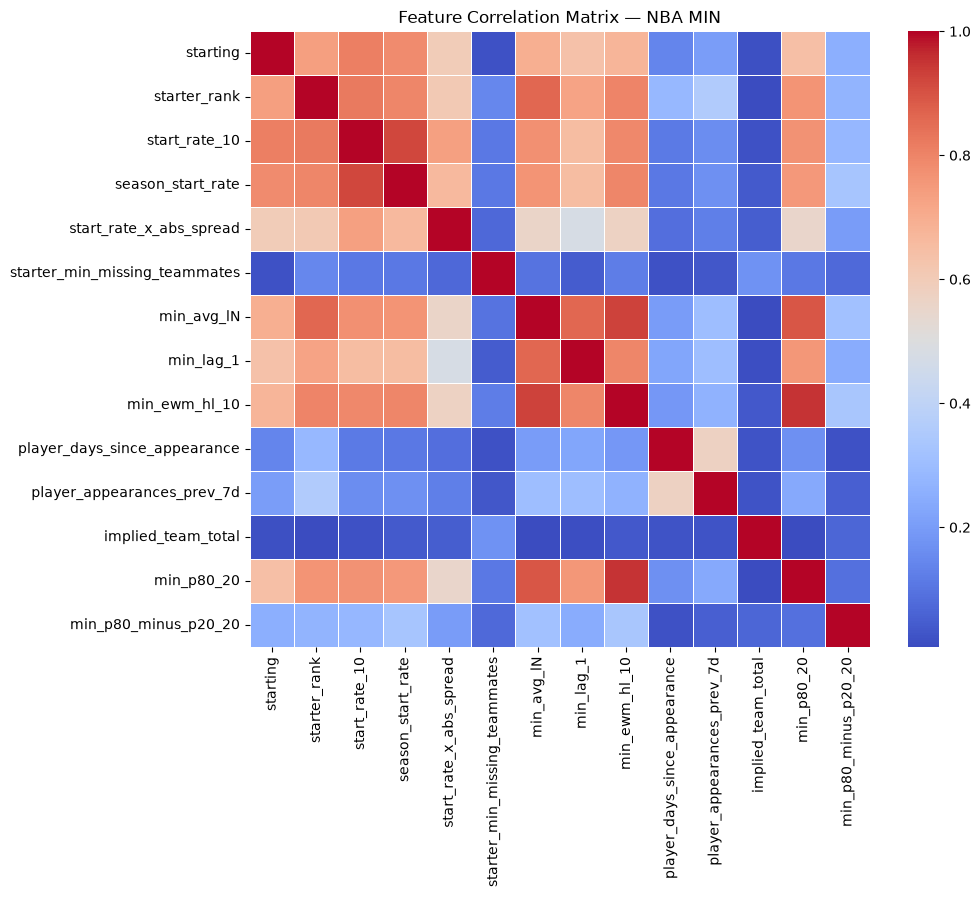

--- High Correlation Report (Threshold > 0.95) ---
min_p80_20 <-> min_ewm_hl_10: 0.9520


['min_p80_20']

In [ ]:
correlated_features = analyze_correlations(
    df, MIN_FEATURES, title="Feature Correlation Matrix — NBA MIN"
)
correlated_features

### Models

In [ ]:
# Hyperparameter tuning
# Leave commented if you don't want to retune the model

# import importlib
# import models.shared.train as train

# importlib.reload(train)
# tune_xgb_quantile = train.tune_xgb_quantile

# result = tune_xgb_quantile(X, y, n_trials=50, n_splits=3)
# XGB_PARAMS = result["best_params"]


In [ ]:
# XGBoost using time series cross validation and walk forward validation

tscv_results = run_timeseries_cv(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)
wf = run_walk_forward(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
    n_folds=5,
)

wf_results = wf["wf_results"]
models_last = wf["models_last"]
preds_last = wf["preds_last"]
X_val_last = wf["X_val_last"]
y_val_last = wf["y_val_last"]
starting_last = wf["starting_last"]
last_fold = wf["last_fold"]


── Phase 1: TimeSeriesSplit (XGBoost) ──────────────────────────

TSCV fold 1
  n=25010
  pinball  | q0.05=0.603  q0.10=1.002  q0.20=1.577  q0.30=1.945  q0.40=2.150  q0.50=2.213  q0.60=2.143  q0.70=1.932  q0.80=1.562  q0.90=0.988  q0.95=0.591
  coverage | 80%=78.6% (target 80%)  90%=89.3% (target 90%)
  Starters   | n=11707 | pinball q50: 2.097 | 80% coverage: 78.4%
  Bench      | n=13303 | pinball q50: 2.316 | 80% coverage: 78.8%
  minute tiers by predicted q50
  <15 min    | n= 5466 | pinball q50: 2.339 | 80% coverage: 78.0%
  15-24 min  | n= 7204 | pinball q50: 2.372 | 80% coverage: 78.8%
  24-31 min  | n= 5996 | pinball q50: 2.227 | 80% coverage: 79.2%
  31+ min    | n= 6344 | pinball q50: 1.911 | 80% coverage: 78.3%

TSCV fold 2
  n=25010
  pinball  | q0.05=0.632  q0.10=1.050  q0.20=1.640  q0.30=2.019  q0.40=2.231  q0.50=2.298  q0.60=2.222  q0.70=1.998  q0.80=1.609  q0.90=1.017  q0.95=0.605
  coverage | 80%=78.2% (target 80%)  90%=88.9% (target 90%)
  Starters   | n=11824 | pinbal

In [ ]:
def score_predictions(y_true, preds, split: str):
    """Pinball loss per quantile and central interval coverage."""
    y_true = np.asarray(y_true, dtype=float)
    pinball_rows = []
    for key, pred in preds.items():
        alpha = float(str(key).split("_", 1)[1])
        pinball_rows.append({
            "split": split,
            "quantile": alpha,
            "pinball": pinball_loss(y_true, pred, alpha),
        })
    coverage_rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        if low_key not in preds or high_key not in preds:
            continue
        coverage_rows.append({
            "split": split,
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
        })
    return pd.DataFrame(pinball_rows), pd.DataFrame(coverage_rows)


wf_pinball, wf_coverage = score_predictions(
    y_val_last, preds_last, last_fold["fold"]
)
display(wf_pinball.round(4))
display(wf_coverage.round(4))

,split,quantile,pinball
0,WF fold 5 (2025-01-02 → 2025-04-11),0.05,0.6035
1,WF fold 5 (2025-01-02 → 2025-04-11),0.10,0.9988
2,WF fold 5 (2025-01-02 → 2025-04-11),0.20,1.5689
3,WF fold 5 (2025-01-02 → 2025-04-11),0.30,1.9335
4,WF fold 5 (2025-01-02 → 2025-04-11),0.40,2.1393
5,WF fold 5 (2025-01-02 → 2025-04-11),0.50,2.2078
6,WF fold 5 (2025-01-02 → 2025-04-11),0.60,2.1409
7,WF fold 5 (2025-01-02 → 2025-04-11),0.70,1.9238
8,WF fold 5 (2025-01-02 → 2025-04-11),0.80,1.5532
9,WF fold 5 (2025-01-02 → 2025-04-11),0.90,0.9852


,split,interval,coverage,target
0,WF fold 5 (2025-01-02 → 2025-04-11),80%,0.8016,0.8
1,WF fold 5 (2025-01-02 → 2025-04-11),90%,0.9027,0.9


In [ ]:
# Test xgboost model on holdout set

holdout = evaluate_holdout(
    ppm_df,
    ppm_holdout,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    wf_results=wf_results,
    quantiles=QUANTILES,
    fold_label=f"{HOLDOUT_SEASON} Blind Holdout",
)
models_ho = holdout["models_ho"]
preds_ho = holdout["preds_ho"]
ho_metrics = holdout["ho_metrics"]
X_ho = holdout["X_ho"]
y_ho = holdout["y_ho"]

ho_pinball, ho_coverage = score_predictions(
    y_ho, preds_ho, f"{HOLDOUT_SEASON} holdout"
)
display(ho_pinball.round(4))
display(ho_coverage.round(4))

── 2025-26 Blind Holdout ─────────────────────────────────────────────────
  Train pool: 90% rows for fit, remainder for early-stopping only; predict holdout (never in eval_set).



2025-26 Blind Holdout
  n=26648
  pinball  | q0.05=0.613  q0.10=1.014  q0.20=1.587  q0.30=1.953  q0.40=2.156  q0.50=2.223  q0.60=2.154  q0.70=1.943  q0.80=1.572  q0.90=0.996  q0.95=0.591
  coverage | 80%=79.6% (target 80%)  90%=89.7% (target 90%)
  Starters   | n=12300 | pinball q50: 2.073 | 80% coverage: 80.8%
  Bench      | n=14348 | pinball q50: 2.351 | 80% coverage: 78.6%
  minute tiers by predicted q50
  <15 min    | n= 6247 | pinball q50: 2.454 | 80% coverage: 77.7%
  15-24 min  | n= 7604 | pinball q50: 2.317 | 80% coverage: 79.6%
  24-31 min  | n= 7212 | pinball q50: 2.164 | 80% coverage: 80.4%
  31+ min    | n= 5585 | pinball q50: 1.912 | 80% coverage: 80.7%

───────────────────────────────────────────────────────
  Walk-forward pinball q50 (mean) : 2.226
  Holdout pinball q50             : 2.223
  Pinball gap                     : -0.003  ✓ acceptable
  Walk-forward 80% coverage (mean): 79.1%
  Holdout 80% coverage            : 79.6%


,split,quantile,pinball
0,2025-26 holdout,0.05,0.6127
1,2025-26 holdout,0.10,1.0138
2,2025-26 holdout,0.20,1.5865
3,2025-26 holdout,0.30,1.9527
4,2025-26 holdout,0.40,2.1560
5,2025-26 holdout,0.50,2.2227
6,2025-26 holdout,0.60,2.1535
7,2025-26 holdout,0.70,1.9431
8,2025-26 holdout,0.80,1.5722
9,2025-26 holdout,0.90,0.9959


,split,interval,coverage,target
0,2025-26 holdout,80%,0.7962,0.8
1,2025-26 holdout,90%,0.8970,0.9


In [ ]:
# empirical quantile calibration
y_true = np.asarray(y_ho, dtype=float)
calibration_rows = []
for key, pred in preds_ho.items():
    alpha = float(str(key).split("_", 1)[1])
    pred = np.asarray(pred, dtype=float)
    empirical = float(np.mean(y_true <= pred))
    calibration_rows.append({
        "quantile": alpha,
        "target": alpha,
        "empirical": empirical,
        "delta": empirical - alpha,
    })
calibration = (
    pd.DataFrame(calibration_rows)
    .sort_values("quantile")
    .reset_index(drop=True)
)

print(f"{HOLDOUT_SEASON} holdout — empirical quantile calibration")
display(calibration.round(4))


2025-26 holdout — empirical quantile calibration


,quantile,target,empirical,delta
0,0.05,0.05,0.0501,0.0001
1,0.10,0.10,0.0997,-0.0003
2,0.20,0.20,0.1936,-0.0064
3,0.30,0.30,0.2945,-0.0055
4,0.40,0.40,0.3949,-0.0051
5,0.50,0.50,0.4973,-0.0027
6,0.60,0.60,0.5982,-0.0018
7,0.70,0.70,0.7001,0.0001
8,0.80,0.80,0.7980,-0.0020
9,0.90,0.90,0.8959,-0.0041


In [ ]:
quantile_keys = sorted(
    preds_ho,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
grid = np.column_stack([
    np.asarray(preds_ho[key], dtype=float) for key in quantile_keys
])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
n_rows = int(len(crossed))
n_crossed = int(crossed.sum())
print(
    f"{HOLDOUT_SEASON} holdout quantile crossing: "
    f"{n_crossed:,} / {n_rows:,} rows ({n_crossed / n_rows:.1%})"
)

pair_rows = []
for left, right in zip(quantile_keys, quantile_keys[1:]):
    pair_rate = float(np.mean(
        np.asarray(preds_ho[left], dtype=float)
        > np.asarray(preds_ho[right], dtype=float)
    ))
    pair_rows.append({
        "lower": left,
        "upper": right,
        "crossing_rate": pair_rate,
    })
crossing_pairs = pd.DataFrame(pair_rows)
display(crossing_pairs.round(4))


2025-26 holdout quantile crossing: 452 / 26,648 rows (1.7%)


,lower,upper,crossing_rate
0,q_0.05,q_0.10,0.0008
1,q_0.10,q_0.20,0.0017
2,q_0.20,q_0.30,0.0028
3,q_0.30,q_0.40,0.0042
4,q_0.40,q_0.50,0.0027
5,q_0.50,q_0.60,0.0025
6,q_0.60,q_0.70,0.0018
7,q_0.70,q_0.80,0.0012
8,q_0.80,q_0.90,0.0003
9,q_0.90,q_0.95,0.0004


In [ ]:
predicted = np.asarray(preds_ho["q_0.50"], dtype=float)
y_true = np.asarray(y_ho, dtype=float)
low_80 = np.asarray(preds_ho["q_0.10"], dtype=float)
high_80 = np.asarray(preds_ho["q_0.90"], dtype=float)
low_90 = np.asarray(preds_ho["q_0.05"], dtype=float)
high_90 = np.asarray(preds_ho["q_0.95"], dtype=float)
width_80 = high_80 - low_80
width_90 = high_90 - low_90

tier_rows = []
for name, fn in MIN_TIERS.items():
    mask = np.asarray(fn(predicted), dtype=bool)
    n = int(mask.sum())
    if n == 0:
        continue
    tier_rows.append({
        "tier": name,
        "n": n,
        "share": n / len(predicted),
        "pinball_q50": pinball_loss(y_true[mask], predicted[mask], 0.50),
        "empirical_q50": float(np.mean(y_true[mask] <= predicted[mask])),
        "coverage_80": interval_coverage(y_true[mask], low_80[mask], high_80[mask]),
        "coverage_90": interval_coverage(y_true[mask], low_90[mask], high_90[mask]),
        "mean_width_80": float(np.mean(width_80[mask])),
        "mean_width_90": float(np.mean(width_90[mask])),
    })
tier_report = pd.DataFrame(tier_rows)
print(f"{HOLDOUT_SEASON} holdout — minute tiers by predicted q50")
display(tier_report.round(4))


2025-26 holdout — minute tiers by predicted q50


,tier,n,share,pinball_q50,empirical_q50,coverage_80,coverage_90,mean_width_80,mean_width_90
0,<15 min,6247,0.2344,2.4538,0.4858,0.7772,0.8838,14.9718,18.9589
1,15-24 min,7604,0.2853,2.3172,0.4846,0.7959,0.8997,15.0186,19.7135
2,24-31 min,7212,0.2706,2.1638,0.5096,0.8045,0.9000,13.8505,17.9616
3,31+ min,5585,0.2096,1.9117,0.5115,0.8070,0.9042,11.9331,15.8496


In [ ]:
# Holdout RMSE, CRPS, and tail calibration.
# CRPS is twice the mean pinball across the trained knots.
# Lower tail: share of outcomes at or below the knot.
# Upper tail: share of outcomes above the knot.

from models.shared.minutes_sampler import row_crps

TAIL_KNOTS = (
    ("lower", 0.05),
    ("lower", 0.10),
    ("upper", 0.90),
    ("upper", 0.95),
)


def holdout_point_distribution(name, y, preds):
    y = np.asarray(y, dtype=float)
    levels = sorted(float(str(key).split("_", 1)[1]) for key in preds)
    grid = np.column_stack(
        [np.asarray(preds[f"q_{level:.2f}"], dtype=float) for level in levels]
    )
    q50 = np.asarray(preds["q_0.50"], dtype=float)
    return {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y, q50))),
        "crps": float(np.mean(row_crps(y, grid, np.asarray(levels)))),
    }


def tail_calibration_rows(name, y, preds):
    y = np.asarray(y, dtype=float)
    rows = []
    for side, level in TAIL_KNOTS:
        knot = np.asarray(preds[f"q_{level:.2f}"], dtype=float)
        if side == "lower":
            nominal = level
            empirical = float(np.mean(y <= knot))
        else:
            nominal = 1.0 - level
            empirical = float(np.mean(y > knot))
        rows.append({
            "model": name,
            "side": side,
            "quantile": level,
            "nominal": nominal,
            "empirical": empirical,
            "delta": empirical - nominal,
        })
    return rows


holdout_models = (
    ("XGBoost", y_ho, preds_ho),
)
score_table = pd.DataFrame(
    [holdout_point_distribution(name, y, preds) for name, y, preds in holdout_models]
)
tail_calibration = pd.DataFrame(
    [
        row
        for name, y, preds in holdout_models
        for row in tail_calibration_rows(name, y, preds)
    ]
)

print(
    f"{HOLDOUT_SEASON} holdout — q50 RMSE and 11-knot CRPS\n"
    "  CRPS is twice the mean pinball across the trained knots"
)
display(score_table.round(4))
print(
    f"{HOLDOUT_SEASON} holdout — tail calibration\n"
    "  delta is empirical minus nominal. "
    "A positive delta means more outcomes landed in that tail than the quantile claims"
)
display(tail_calibration.round(4))


In [ ]:
def interval_sharpness(y_true, preds):
    y_true = np.asarray(y_true, dtype=float)
    rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        width = (
            np.asarray(preds[high_key], dtype=float)
            - np.asarray(preds[low_key], dtype=float)
        )
        rows.append({
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
            "mean_width": float(np.mean(width)),
            "median_width": float(np.median(width)),
        })
    return pd.DataFrame(rows)

sharp_xgb = interval_sharpness(y_ho, preds_ho)

print(f"{HOLDOUT_SEASON} holdout — interval sharpness (minutes)")
display(sharp_xgb.round(4))


### Baseline

In [ ]:
N_BOOT = 2_000
SEED = 42
WIS_INTERVALS = (
    (0.80, "q_0.40", "q_0.60"),
    (0.60, "q_0.30", "q_0.70"),
    (0.40, "q_0.20", "q_0.80"),
    (0.20, "q_0.10", "q_0.90"),
    (0.10, "q_0.05", "q_0.95"),
)

XGB_NAME = "Quantile XGBoost"

y_all = np.asarray(y_ho, dtype=float)
model_quantiles = {
    XGB_NAME: {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()},
}
for name, qmap in model_quantiles.items():
    if len(next(iter(qmap.values()))) != len(y_all):
        raise ValueError(f"{name} predictions do not match the holdout length")
alpha_of = {
    key: float(str(key).split("_", 1)[1]) for key in model_quantiles[XGB_NAME]
}
ordered_keys = sorted(model_quantiles[XGB_NAME], key=alpha_of.get)
baselines = {
    "Last-game minutes": ppm_holdout["min_lag_1"].to_numpy(dtype=float),
    "Season-to-date average": ppm_holdout["season_min_mean"].to_numpy(dtype=float),
    "EWMA minutes": ppm_holdout["min_ewm_hl_10"].to_numpy(dtype=float),
}
paired = np.isfinite(y_all)
for qmap in model_quantiles.values():
    paired &= np.isfinite(qmap["q_0.50"])
for pred in baselines.values():
    paired &= np.isfinite(pred)

def point_row(name, y, pred):
    error = y - pred
    absolute = np.abs(error)
    return {
        "model": name,
        "mae": float(absolute.mean()),
        "median_ae": float(np.median(absolute)),
        "mean_bias": float(error.mean()),
    }

def interval_score(y, lower, upper, alpha):
    width = upper - lower
    below = y < lower
    above = y > upper
    return (
        width
        + (2.0 / alpha) * (lower - y) * below
        + (2.0 / alpha) * (y - upper) * above
    )

def wis_values(y, qmap):
    present = [
        (alpha, qmap[low], qmap[high])
        for alpha, low, high in WIS_INTERVALS
        if low in qmap and high in qmap
    ]
    total = 0.5 * np.abs(y - qmap["q_0.50"])
    for alpha, lower, upper in present:
        total = total + (alpha / 2.0) * interval_score(y, lower, upper, alpha)
    return total / (len(present) + 0.5)

def clustered_mae_bootstrap(y, predictors, dates, n_boot, seed):
    codes, _ = pd.factorize(dates, sort=False)
    n_clusters = int(codes.max()) + 1
    cluster_n = np.bincount(codes).astype(float)
    cluster_sum = {
        name: np.bincount(codes, weights=np.abs(y - pred))
        for name, pred in predictors.items()
    }
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, n_clusters, size=(n_boot, n_clusters))
    weights = np.zeros((n_boot, n_clusters), dtype=np.int32)
    np.add.at(
        weights,
        (np.repeat(np.arange(n_boot), n_clusters), draws.ravel()),
        1,
    )
    denom = weights @ cluster_n
    return {name: (weights @ total) / denom for name, total in cluster_sum.items()}

y_paired = y_all[paired]
xgb_q50_name = f"{XGB_NAME} q50"
paired_preds = {
    xgb_q50_name: model_quantiles[XGB_NAME]["q_0.50"][paired],
}
paired_preds.update({name: pred[paired] for name, pred in baselines.items()})
dates_paired = pd.to_datetime(ppm_holdout["game_date"]).to_numpy()[paired]
boot_mae = clustered_mae_bootstrap(
    y_paired, paired_preds, dates_paired, N_BOOT, SEED
)

point_order = [
    "Last-game minutes",
    "Season-to-date average",
    "EWMA minutes",
    xgb_q50_name,
]
point_table = pd.DataFrame([
    point_row(name, y_paired, paired_preds[name]) for name in point_order
])
best_name = min(baselines, key=lambda name: point_table.loc[
    point_table["model"] == name, "mae"
].iloc[0])
model_boot = boot_mae[xgb_q50_name]
delta_table = pd.DataFrame([
    {
        "comparison": f"XGBoost q50 − {name}",
        "delta_mae": float(
            point_table.loc[point_table["model"] == xgb_q50_name, "mae"].iloc[0]
            - point_table.loc[point_table["model"] == name, "mae"].iloc[0]
        ),
        "ci_low": float(np.quantile(model_boot - boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(model_boot - boot_mae[name], 0.975)),
    }
    for name in point_order[:-1]
])

fold_rows = []
for fold in wf_results:
    part = ppm_df.loc[fold["val_mask"]]
    y_fold = part[TARGET_COL].to_numpy(dtype=float)
    fold_row = {
        "fold": fold["fold"],
        "n": int(len(part)),
        "model_mae": 2.0 * float(fold["pinball"]),
    }
    for name, column in (
        ("last_game", "min_lag_1"),
        ("season_average", "season_min_mean"),
        ("ewma", "min_ewm_hl_10"),
    ):
        pred = part[column].to_numpy(dtype=float)
        ok = np.isfinite(y_fold) & np.isfinite(pred)
        fold_row[name] = float(np.mean(np.abs(y_fold[ok] - pred[ok])))
    fold_row["best_baseline"] = min(
        fold_row["last_game"], fold_row["season_average"], fold_row["ewma"]
    )
    fold_row["model_minus_best"] = fold_row["model_mae"] - fold_row["best_baseline"]
    fold_rows.append(fold_row)
fold_table = pd.DataFrame(fold_rows)

print("1. Point accuracy versus baselines")
print(
    f"Identical holdout rows: {int(paired.sum()):,}  |  "
    f"dropped {int((~paired).sum()):,} with a missing baseline  |  "
    f"{N_BOOT:,} date-clustered resamples"
)
print(
    "Mean bias is actual minus predicted. "
    f"XGBoost q50 pinball {pinball_loss(y_paired, paired_preds[xgb_q50_name], 0.50):.4f}. "
    "That equals half the q50 MAE."
)
display(point_table.round(3))
print("Paired MAE difference, clustered by game date. Negative means XGBoost q50 is lower.")
display(delta_table.round(3))
print(
    "Walk-forward MAE is 2 × q50 pinball on every validation row. "
    "Baseline MAE drops rows with no prior."
)
display(fold_table.round(3))

def interval_stats(y, qmap, low, high):
    low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
    if low_key not in qmap or high_key not in qmap:
        return {"cov": np.nan, "width_mean": np.nan, "width_median": np.nan}
    width = qmap[high_key] - qmap[low_key]
    return {
        "cov": interval_coverage(y, qmap[low_key], qmap[high_key]),
        "width_mean": float(np.mean(width)),
        "width_median": float(np.median(width)),
    }

def distribution_row(name, y, qmap):
    band_80 = interval_stats(y, qmap, 0.10, 0.90)
    band_90 = interval_stats(y, qmap, 0.05, 0.95)
    keys = sorted(qmap, key=lambda key: float(str(key).split("_", 1)[1]))
    grid = np.column_stack([qmap[key] for key in keys])
    if grid.shape[1] < 2:
        crossed = 0.0
    else:
        crossed = float(np.mean(np.any(np.diff(grid, axis=1) < 0, axis=1)))
    return {
        "model": name,
        "cov_80": band_80["cov"],
        "width_80_mean": band_80["width_mean"],
        "width_80_median": band_80["width_median"],
        "cov_90": band_90["cov"],
        "width_90_mean": band_90["width_mean"],
        "width_90_median": band_90["width_median"],
        "wis": float(np.mean(wis_values(y, qmap))),
        "quantile_crossing": crossed,
    }

print("\n2. Distribution quality")
wis_knots = [
    f"{low}–{high}"
    for _alpha, low, high in WIS_INTERVALS
    if low in model_quantiles[XGB_NAME] and high in model_quantiles[XGB_NAME]
]
print(
    "WIS uses the trained knots only: "
    + (", ".join(wis_knots) if wis_knots else "median only")
    + ", plus the q50 term."
)
distribution = pd.DataFrame([
    distribution_row(name, y_all, qmap) for name, qmap in model_quantiles.items()
])
display(distribution.round(4))
xgb_dist = distribution.loc[distribution["model"] == XGB_NAME].iloc[0]
print(
    f"Best baseline MAE {point_table.loc[point_table['model'] == best_name, 'mae'].iloc[0]:.3f} "
    f"({best_name}) is that point forecast's CRPS."
)

print("\n3. Calibration of every quantile")
calibration = pd.DataFrame([
    {
        "model": name,
        "quantile": f"q{alpha_of[key] * 100:02.0f}",
        "expected": alpha_of[key],
        "observed": float(np.mean(y_all <= qmap[key])),
        "difference": float(np.mean(y_all <= qmap[key]) - alpha_of[key]),
    }
    for name, qmap in model_quantiles.items()
    for key in sorted(qmap, key=lambda key: float(str(key).split("_", 1)[1]))
])
display(calibration.round(4))

def subgroup_rows_for(group, mask):
    rows = []
    base = np.asarray(mask, dtype=bool) & np.isfinite(y_all)
    for name, qmap in model_quantiles.items():
        use = base & np.isfinite(qmap["q_0.50"])
        n = int(use.sum())
        if n == 0:
            continue
        y = y_all[use]
        part = {key: values[use] for key, values in qmap.items()}
        error = y - part["q_0.50"]
        band_80 = interval_stats(y, part, 0.10, 0.90)
        band_90 = interval_stats(y, part, 0.05, 0.95)
        rows.append({
            "model": name,
            "group": group,
            "n": n,
            "mae": float(np.mean(np.abs(error))),
            "bias": float(np.mean(error)),
            "wis": float(np.mean(wis_values(y, part))),
            "cov_80": band_80["cov"],
            "width_80_mean": band_80["width_mean"],
            "width_80_median": band_80["width_median"],
            "cov_90": band_90["cov"],
            "width_90_mean": band_90["width_mean"],
            "width_90_median": band_90["width_median"],
        })
    return rows

print("\n4. Pregame-defined subgroups")
print("Minute tiers use predicted q50.")
starting = ppm_holdout["starting"].to_numpy()
months = pd.to_datetime(ppm_holdout["game_date"]).dt.to_period("M").astype(str)
xgb_q50 = model_quantiles[XGB_NAME]["q_0.50"]
subgroup_rows = []
subgroup_rows.extend(subgroup_rows_for("Confirmed starter", starting == 1))
subgroup_rows.extend(subgroup_rows_for("Bench", starting == 0))
for name, fn in MIN_TIERS.items():
    subgroup_rows.extend(subgroup_rows_for(f"Predicted q50 {name}", fn(xgb_q50)))
for month in sorted(months.unique()):
    subgroup_rows.extend(subgroup_rows_for(str(month), months.to_numpy() == month))
subgroup_table = pd.DataFrame(subgroup_rows)
display(subgroup_table.round(3))

print("\n5. Tail failures")
tail_rows = []
for name, qmap in model_quantiles.items():
    absolute_error = np.abs(y_all - qmap["q_0.50"])
    for cutoff in (5, 10, 15):
        tail_rows.append({
            "model": name,
            "threshold": f">{cutoff:g} min",
            "rate": float(np.mean(absolute_error > cutoff)),
            "n": int(np.sum(absolute_error > cutoff)),
        })
tail_table = pd.DataFrame(tail_rows)
display(tail_table.round(4))

xgb_cal = calibration.loc[calibration["model"] == XGB_NAME]
best_delta = delta_table.loc[
    delta_table["comparison"] == f"XGBoost q50 − {best_name}"
].iloc[0]
best_mae = float(point_table.loc[point_table["model"] == best_name, "mae"].iloc[0])
print("\nChecks from this frame")
q50_rate = float(xgb_cal.loc[xgb_cal["quantile"] == "q50", "observed"].iloc[0])
max_gap = float(xgb_cal["difference"].abs().max())
print(f"  {XGB_NAME} q50 observed rate {q50_rate:.1%}  (target about 48–52%)")
print(f"  {XGB_NAME} largest |quantile gap| {max_gap:.1%}")
print(
    f"  XGBoost q50 vs {best_name}: delta MAE {best_delta['delta_mae']:+.3f} "
    f"[{best_delta['ci_low']:+.3f}, {best_delta['ci_high']:+.3f}]"
)
print(
    f"  WIS {xgb_dist['wis']:.3f} (XGBoost) "
    f"vs best baseline CRPS/MAE {best_mae:.3f}"
)
print(
    "  walk-forward folds with XGBoost MAE below the best baseline: "
    f"{int((fold_table['model_minus_best'] < 0).sum())} / {len(fold_table)}"
)
print(
    f"  raw quantile crossing {xgb_dist['quantile_crossing']:.2%}"
)


### Features Analysis

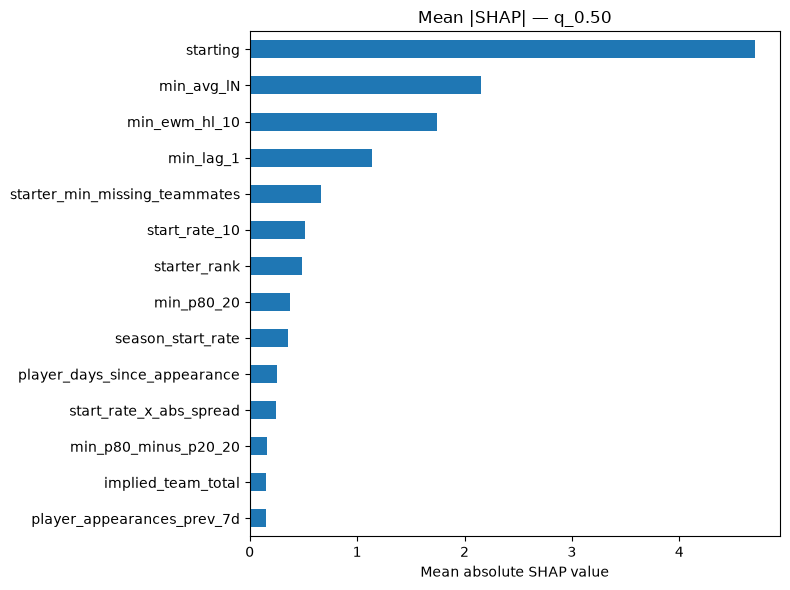

In [ ]:
import shap

model = models_last["q_0.50"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature": X_val_last.columns,
        "importance": result.importances_mean,
        "std": result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"] = pi_df["std"].round(5)
pi_df["p_value"] = sp_stats.ttest_1samp(result.importances, 0.0, axis=1).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())

Permutation importance (val set) — higher = more important, significant = p<0.05
                          feature  importance      std  p_value  significant
1                        starting     1.01525  0.01226      0.0         True
2                      min_avg_lN     0.45809  0.00629      0.0         True
3                   min_ewm_hl_10     0.35794  0.00619      0.0         True
4                    starter_rank     0.28693  0.00532      0.0         True
5                       min_lag_1     0.16437  0.00504      0.0         True
6   starter_min_missing_teammates     0.08194  0.00380      0.0         True
7                      min_p80_20     0.06010  0.00279      0.0         True
8               season_start_rate     0.05443  0.00324      0.0         True
9                   start_rate_10     0.04955  0.00314      0.0         True
10        start_rate_x_abs_spread     0.02043  0.00179      0.0         True
11   player_days_since_appearance     0.01939  0.00237      0.0         

In [ ]:
train_mask_last = last_fold["train_mask"]
val_mask_last = last_fold["val_mask"]
X_tr_last = X.loc[train_mask_last]
X_va_last = X.loc[val_mask_last]
y_tr_last = ppm_df.loc[train_mask_last, TARGET_COL]
y_va_last = ppm_df.loc[val_mask_last, TARGET_COL]

ablation_df = run_feature_ablation(
    MIN_FEATURES, X_tr_last, y_tr_last, X_va_last, y_va_last,
    xgb_params=XGB_PARAMS,
)

Baseline pinball q50 (all features): 2.2024
                          feature  ablated_pinball  delta_pinball
1                        starting           2.3000         0.0976
2   starter_min_missing_teammates           2.2516         0.0493
3                       min_lag_1           2.2222         0.0198
4                      min_avg_lN           2.2174         0.0150
5                    starter_rank           2.2109         0.0085
6                   min_ewm_hl_10           2.2079         0.0056
7                   start_rate_10           2.2056         0.0032
8                      min_p80_20           2.2052         0.0028
9    player_days_since_appearance           2.2036         0.0013
10     player_appearances_prev_7d           2.2036         0.0012
11              season_start_rate           2.2029         0.0005
12        start_rate_x_abs_spread           2.2024        -0.0000
13             implied_team_total           2.2022        -0.0002
14           min_p80_minus_p20_2

In [ ]:
from scipy import stats

model = models_last["q_0.50"]
_shap_expl = shap.TreeExplainer(model, model_output="raw")
_shap_vals = _shap_expl(X_val_last)
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature": X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int))

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature": X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(result.importances, 0.0, axis=1, nan_policy="omit").pvalue,
})

abla = ablation_df[["feature", "delta_pinball"]].rename(columns={"delta_pinball": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": MIN_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv, on="feature", how="left")
    .merge(abla, on="feature", how="left")
)

_ms = feature_audit["mean_abs_shap"].astype(float)
_mp = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()
feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2
feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1
feature_audit["keep"] = (feature_audit["perm_pvalue"] < 0.05) & (feature_audit["ablation_delta"] > 0)

print(feature_audit.to_string())

                          feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1                        starting       4.702447          1          1          1.01525              0.01226  3.505464e-57          0.0976   1.000000   1.000000   1.000000   True
2                      min_avg_lN       2.154418          2          2          0.45809              0.00629  1.460555e-55          0.0150   0.458148   0.451209   0.454679   True
3                   min_ewm_hl_10       1.742720          3          3          0.35794              0.00619  1.162411e-52          0.0056   0.370599   0.352563   0.361581   True
4                       min_lag_1       1.141531          4          5          0.16437              0.00504  1.862818e-45          0.0198   0.242752   0.161901   0.202327   True
5                    starter_rank       0.489904          7          4          0.28693              0.00

### Slice Analysis

In [ ]:
import importlib

import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
from models.shared.artifacts import monotonize_quantiles

dates = pd.to_datetime(ppm_holdout["game_date"])
y_all = np.asarray(y_ho, dtype=float)
raw_q = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
model = raw_q["q_0.50"]

def slice_score(name, mask, qmap):
    mask = np.asarray(mask, dtype=bool)
    n = int(mask.sum())
    if n == 0:
        return {"slice": name, "n": 0}
    y = y_all[mask]
    qmap = {key: values[mask] for key, values in qmap.items()}
    error = y - qmap["q_0.50"]
    return {
        "slice": name,
        "n": n,
        "mae": float(np.mean(np.abs(error))),
        "bias": float(np.mean(error)),
        "p_actual_le_q50": float(np.mean(y <= qmap["q_0.50"])),
        "cov_80": interval_coverage(y, qmap["q_0.10"], qmap["q_0.90"]),
        "mean_width_80": float(np.mean(qmap["q_0.90"] - qmap["q_0.10"])),
        "wis": float(np.mean(wis_values(y, qmap))),
    }

print("1. April is late regular season, not the postseason")
holdout_season = df.loc[df["season_year"].astype("string").eq(str(HOLDOUT_SEASON))]
print(holdout_season["season_type"].astype("string").value_counts(dropna=False).to_string())
print(
    f"Holdout dates {dates.min().date()} \u2192 {dates.max().date()}. "
    "The silver store only has regular_season gamelogs, so playoff games are not in this test."
)
blocks = {
    "October\u2013February": dates < "2026-03-01",
    "March 1\u201314": (dates >= "2026-03-01") & (dates < "2026-03-15"),
    "March 15\u201331": (dates >= "2026-03-15") & (dates < "2026-04-01"),
    "April regular season": dates >= "2026-04-01",
}
calendar = pd.DataFrame([slice_score(name, mask, raw_q) for name, mask in blocks.items()])
display(calendar.round(3))
print(
    "Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the "
    "regular season. It is not a postseason effect, and the model has not been tested on playoff games."
)

print("\n2. Starter and bench mean bias versus median calibration")
starting = ppm_holdout["starting"].to_numpy()
role = pd.DataFrame([
    slice_score("Confirmed starter", starting == 1, raw_q),
    slice_score("Bench", starting == 0, raw_q),
])
display(role.round(3))
for _, row in role.iterrows():
    if row["n"] == 0:
        continue
    gap = row["p_actual_le_q50"] - 0.50
    if abs(gap) <= 0.02:
        reading = "q50 is near 50%, so the mean bias is skew around a calibrated median"
    elif gap > 0:
        reading = "q50 is too high: actuals fall under the median more often than 50%"
    else:
        reading = "q50 is too low: actuals fall under the median less often than 50%"
    print(
        f"  {row['slice']}: bias {row['bias']:+.2f} min, "
        f"P(actual <= q50) {row['p_actual_le_q50']:.1%}. {reading}."
    )

print("\n3. Monotone rearrangement")
ordered_keys = sorted(raw_q, key=lambda key: float(str(key).split("_", 1)[1]))
grid = np.column_stack([raw_q[key] for key in ordered_keys])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
preds_ho_mono = monotonize_quantiles(raw_q)
mono_grid = np.column_stack([preds_ho_mono[key] for key in ordered_keys])
shift = pd.DataFrame([
    {
        "quantile": key,
        "mean_abs_shift": float(np.mean(np.abs(preds_ho_mono[key] - raw_q[key]))),
        "share_changed": float(np.mean(preds_ho_mono[key] != raw_q[key])),
    }
    for key in ordered_keys
])
print(
    f"Crossing before {crossed.mean():.2%} of rows; "
    f"after rearrangement {np.any(np.diff(mono_grid, axis=1) < 0, axis=1).mean():.2%}."
)
display(shift.round(4))
print("Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.")

print("\n4. Cold-start and missing-baseline rows")
lag = ppm_holdout["min_lag_1"].to_numpy(dtype=float)
season_avg = ppm_holdout["season_min_mean"].to_numpy(dtype=float)
ewma = ppm_holdout["min_ewm_hl_10"].to_numpy(dtype=float)
cold = ~np.isfinite(lag)
season_opener = np.isfinite(lag) & ~np.isfinite(season_avg)
missing_any = cold | season_opener | ~np.isfinite(ewma)
print(
    f"Missing any baseline: {int(missing_any.sum()):,} | "
    f"no prior game (min_lag_1 missing): {int(cold.sum()):,} | "
    f"season opener with history: {int(season_opener.sum()):,}"
)

role_quantiles = {}
for role_value, role_name in ((1, "starter"), (0, "bench")):
    history = ppm_df.loc[ppm_df["starting"] == role_value, "minutes"].to_numpy(dtype=float)
    history = history[np.isfinite(history)]
    role_quantiles[role_name] = {
        key: float(np.quantile(history, float(str(key).split("_", 1)[1])))
        for key in ordered_keys
    }
fallback_q = {key: preds_ho_mono[key].copy() for key in ordered_keys}
for key in ordered_keys:
    fallback_q[key][cold & (starting == 1)] = role_quantiles["starter"][key]
    fallback_q[key][cold & (starting == 0)] = role_quantiles["bench"][key]

missing_table = pd.DataFrame([
    slice_score("Season opener, model", season_opener, raw_q),
    slice_score("No prior game, model", cold, raw_q),
    slice_score("No prior game, role fallback", cold, fallback_q),
    slice_score("Any missing baseline, model", missing_any, raw_q),
])
display(missing_table.round(3))
print(
    "Live fallback: if min_lag_1 exists, predict with the quantile model and then "
    "sort that row into increasing quantile order, even when season_min_mean is missing. "
    "If min_lag_1 is missing, do not use the tree. Use the training-pool minute quantiles "
    "for the confirmed role (starter or bench). preds_ho_live applies that rule."
)
preds_ho_live = fallback_q


1. April is late regular season, not the postseason
season_type
Regular Season    26648
Holdout dates 2025-10-21 → 2026-04-12. The silver store only has regular_season gamelogs, so playoff games are not in this test.


NameError: name 'wis_values' is not defined

### Error Analysis

In [ ]:
# Holdout misses. Score, fouls, and plus/minus are post-game context.
# They explain a miss; they were not inputs to the model.
ctx = (
    df[[
        "game_id", "player_id", "team_abbreviation", "matchup", "wl",
        "pf", "pfd", "pts", "plus_minus", "team_pts", "opp_pts",
        "abs_spread",
    ]]
    .drop_duplicates(["game_id", "player_id"])
)
team_minutes = (
    df.groupby(["game_id", "team_abbreviation"], as_index=False)["minutes"]
    .sum()
    .rename(columns={"minutes": "team_minutes"})
)

miss = ppm_holdout.reset_index(drop=True).copy()
miss["q10"] = np.asarray(preds_ho["q_0.10"], dtype=float)
miss["q50"] = np.asarray(preds_ho["q_0.50"], dtype=float)
miss["q90"] = np.asarray(preds_ho["q_0.90"], dtype=float)
miss["error"] = miss["minutes"] - miss["q50"]
miss["abs_error"] = miss["error"].abs()
miss = miss.merge(ctx, on=["game_id", "player_id"], how="left")
miss = miss.merge(team_minutes, on=["game_id", "team_abbreviation"], how="left")
miss["game_date"] = pd.to_datetime(miss["game_date"]).dt.date
miss["score"] = (
    miss["team_pts"].round().astype("Int64").astype("string")
    + "-"
    + miss["opp_pts"].round().astype("Int64").astype("string")
)
miss["margin"] = miss["team_pts"] - miss["opp_pts"]
miss["ot"] = miss["team_minutes"] >= 260
miss["band"] = (
    miss["q10"].round().astype("Int64").astype("string")
    + "–"
    + miss["q90"].round().astype("Int64").astype("string")
)

sat_early = miss["error"] <= -8
played_more = miss["error"] >= 8
blowout = miss["margin"].abs() >= 15
outside_80 = (miss["minutes"] < miss["q10"]) | (miss["minutes"] > miss["q90"])
miss["hint"] = np.select(
    [
        (miss["pf"] >= 6) & sat_early,
        (miss["pf"] >= 5) & sat_early,
        blowout & sat_early & (miss["starting"] == 1),
        blowout & played_more & (miss["starting"] == 0),
        miss["ot"] & played_more,
        (miss["starting"] == 0) & (miss["min_lag_1"] >= 20) & (miss["error"] <= -10),
        (miss["starting"] == 1) & (miss["min_lag_1"].fillna(0) < 15) & (miss["error"] >= 10),
        outside_80,
    ],
    [
        "fouled out",
        "foul trouble",
        "blowout rest",
        "garbage time",
        "overtime",
        "unexpected bench",
        "unexpected start",
        "outside 10–90",
    ],
    default="",
)

show = [
    "game_date", "player_name", "matchup", "score", "wl",
    "minutes", "q50", "error", "band", "pf", "pfd",
    "starting", "pts", "plus_minus", "margin",
    "min_lag_1", "season_min_mean", "abs_spread", "ot", "hint",
]
labels = {
    "game_date": "date",
    "player_name": "player",
    "matchup": "game",
    "minutes": "actual_min",
    "q50": "pred_q50",
    "error": "actual − q50",
    "band": "q10–q90",
    "pf": "fouls",
    "pfd": "fouls_drawn",
    "plus_minus": "+/-",
    "min_lag_1": "last_game_min",
    "season_min_mean": "season_avg",
    "abs_spread": "pregame_|spread|",
}

def show_misses(frame, title):
    view = frame[show].rename(columns=labels).round(1)
    print(title)
    display(view)

way_off = miss["abs_error"] >= 10
print(
    f"{HOLDOUT_SEASON} holdout: {int(way_off.sum()):,} / {len(miss):,} rows "
    f"missed by 10+ minutes ({way_off.mean():.1%}). "
    f"Median |error| {miss['abs_error'].median():.1f}."
)
print("actual − q50 > 0 means he played more than the median prediction.")

show_misses(
    miss.nsmallest(20, "error"),
    "\nPlayed much less than q50 (sat, foul trouble, blowout rest)",
)
show_misses(
    miss.nlargest(20, "error"),
    "\nPlayed much more than q50 (garbage time, overtime, unexpected run)",
)

biggest = pd.concat(
    [miss.nsmallest(20, "error"), miss.nlargest(20, "error")],
    ignore_index=True,
)
print("\nHints on those 40 misses")
print(biggest["hint"].replace("", "unlabeled").value_counts().to_string())

rotation = miss["q50"] >= 15
off_players = (
    miss.loc[rotation & (miss["abs_error"] >= 10)]
    .sort_values("abs_error", ascending=False)
    .groupby(["game_id", "team_abbreviation"])
    .apply(
        lambda g: ", ".join(
            f"{row.player_name} ({row.error:+.0f}, {int(row.pf)} PF)"
            for row in g.itertuples()
        ),
        include_groups=False,
    )
    .rename("players_off_by_10")
    .reset_index()
)
games = (
    miss.loc[rotation]
    .groupby(["game_id", "game_date", "team_abbreviation", "matchup", "score", "wl"], as_index=False)
    .agg(
        n_rotation=("player_id", "size"),
        n_off_10=("abs_error", lambda s: int((s >= 10).sum())),
        mean_abs_error=("abs_error", "mean"),
        margin=("margin", "mean"),
        ot=("ot", "max"),
    )
    .merge(off_players, on=["game_id", "team_abbreviation"], how="left")
    .sort_values(["n_off_10", "mean_abs_error"], ascending=False)
)
print("\nTeam-games where the most rotation players (q50 ≥ 15) missed by 10+ minutes")
display(
    games.head(15)[
        [
            "game_date", "matchup", "score", "wl", "margin", "ot",
            "n_rotation", "n_off_10", "mean_abs_error", "players_off_by_10",
        ]
    ].rename(columns={"game_date": "date", "matchup": "game"}).round(1)
)

2025-26 holdout: 2,269 / 26,648 rows missed by 10+ minutes (8.5%). Median |error| 3.5.
actual − q50 > 0 means he played more than the median prediction.


KeyError: "['pts', 'season_min_mean'] not in index"

### Save Exploratory Artifact

In [ ]:
from datetime import datetime, timezone

def _iso_date(value):
    return pd.Timestamp(value).date().isoformat()

metadata = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "status": "exploratory",
    "model_name": "quantile_xgboost",
    "artifact_stem": ARTIFACT_STEM,
    "features": list(MIN_FEATURES),
    "label": TARGET_COL,
    "label_rule": "minutes > 0",
    "quantiles": list(QUANTILES),
    "point_forecast": 0.50,
    "interval": [0.10, 0.90],
    "params": {
        key: XGB_PARAMS[key]
        for key in (
            "objective",
            "n_estimators",
            "max_depth",
            "learning_rate",
            "subsample",
            "colsample_bytree",
            "reg_alpha",
            "reg_lambda",
            "min_child_weight",
            "early_stopping_rounds",
            "random_state",
        )
    },
    "seed": SEED,
    "train_range": [
        _iso_date(ppm_df["game_date"].min()),
        _iso_date(ppm_df["game_date"].max()),
    ],
    "holdout_season": HOLDOUT_SEASON,
    "holdout_range": [
        _iso_date(ppm_holdout["game_date"].min()),
        _iso_date(ppm_holdout["game_date"].max()),
    ],
    "primary_metric": "q50 pinball",
    "test_metrics": {
        "n": ho_metrics["n"],
        "pinball_q50": ho_metrics["pinball"],
        "coverage_80": ho_metrics.get("coverage_80pct"),
        "coverage_90": ho_metrics.get("coverage_90pct"),
        "walk_forward_pinball_q50": float(
            np.mean([row["pinball"] for row in wf_results])
        ),
    },
}
display(metadata)

{'created_at': '2026-10-05T14:10:51.217485+00:00',
 'status': 'exploratory',
 'model_name': 'quantile_xgboost',
 'artifact_stem': 'min_nba_model',
 'features': ['starting',
  'starter_rank',
  'start_rate_10',
  'season_start_rate',
  'start_rate_x_abs_spread',
  'starter_min_missing_teammates',
  'min_avg_lN',
  'min_lag_1',
  'min_ewm_hl_10',
  'player_days_since_appearance',
  'player_appearances_prev_7d',
  'implied_team_total',
  'min_p80_20',
  'min_p80_minus_p20_20'],
 'label': 'minutes',
 'label_rule': 'minutes > 0',
 'quantiles': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95],
 'point_forecast': 0.5,
 'interval': [0.1, 0.9],
 'params': {'objective': 'reg:quantileerror',
  'n_estimators': 1198,
  'max_depth': 4,
  'learning_rate': 0.10831429032170246,
  'subsample': 0.7978199709619458,
  'colsample_bytree': 0.8074992328271139,
  'reg_alpha': 4.019094324629617,
  'reg_lambda': 0.7852113626147341,
  'min_child_weight': 8,
  'early_stopping_rounds': 50,
  'random_state'

In [ ]:
import importlib
import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
save_model_bundle = artifact_mod.save_model_bundle
load_model_bundle = artifact_mod.load_model_bundle

save_path = save_model_bundle(
    models_ho,
    train_df=ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    ho_metrics=ho_metrics,
    features=MIN_FEATURES,
    artifact_stem=ARTIFACT_STEM,
    metadata=metadata,
)

bundle = load_model_bundle(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

assert list(X_ho.columns) == list(feature_names)
quantile_keys = sorted(
    models_loaded,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
loaded_preds = pd.DataFrame({
    key: models_loaded[key].predict(X_ho) for key in quantile_keys
})
print("Saved quantiles:", ", ".join(loaded_preds.columns))
print(
    f"Loaded model pinball q50 (holdout): "
    f"{pinball_loss(y_ho, loaded_preds['q_0.50'], 0.50):.3f}"
)
print(
    f"Loaded model 80% coverage (holdout): "
    f"{interval_coverage(y_ho, loaded_preds['q_0.10'], loaded_preds['q_0.90']):.1%}"
)
print(f"Trained on data up to      : {bundle['train_end'].date()}")
print(f"Holdout through            : {bundle['val_end'].date()}")

loaded_preds.head(3)


Saved to /Users/alexgonzalez/Documents/nba_quant/models/saved_models/min_nba_model_2026-04-12.joblib
Loaded /Users/alexgonzalez/Documents/nba_quant/models/saved_models/min_nba_model_2026-04-12.joblib
Saved quantiles: q_0.05, q_0.10, q_0.20, q_0.30, q_0.40, q_0.50, q_0.60, q_0.70, q_0.80, q_0.90, q_0.95
Loaded model pinball q50 (holdout): 2.223
Loaded model 80% coverage (holdout): 79.6%
Trained on data up to      : 2025-04-13
Holdout through            : 2026-04-12


,q_0.05,q_0.10,q_0.20,q_0.30,q_0.40,q_0.50,q_0.60,q_0.70,q_0.80,q_0.90,q_0.95
0,25.084507,27.343731,30.173038,31.725718,33.499477,33.731739,34.771233,36.576481,37.175987,38.701221,39.942554
1,10.603515,13.300766,16.417936,17.248497,19.016136,21.502867,22.790421,24.116793,25.812283,27.710629,29.684299
2,23.441135,26.728693,29.660019,30.787821,32.799599,34.041065,34.510849,35.775017,36.398289,37.790470,38.793404


In [ ]:
# Walk-forward and holdout predictions for scripts/build_oos_table.py

from models.shared.oos import holdout_prediction_frame, oof_prediction_frame

PREDICTIONS_PATH = ROOT / "data/oos/nba/minutes_predictions.parquet"

wf_oof = wf["oof"]
folds_found = sorted(int(fold) for fold in wf_oof["fold_id"].unique())
assert folds_found == [1, 2, 3, 4, 5], f"expected 5 walk-forward folds, got {folds_found}"

walk_forward_rows = oof_prediction_frame(wf_oof, ppm_df).assign(
    starting=wf_oof["starting"].to_numpy(),
    early_stop=wf_oof["early_stop"].to_numpy(),
    train_tail_frac=wf_oof["train_tail_frac"].to_numpy(),
)
holdout_rows = holdout_prediction_frame(ppm_holdout, preds_ho).assign(
    starting=ppm_holdout[ROLE_COL].to_numpy(),
)
predictions = pd.concat([walk_forward_rows, holdout_rows], ignore_index=True)
PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
predictions.to_parquet(PREDICTIONS_PATH, index=False)

print(f"Wrote {len(predictions):,} rows to {PREDICTIONS_PATH.relative_to(ROOT)}")
predictions.groupby("window_id").agg(
    rows=("game_id", "size"),
    first=("game_date", "min"),
    last=("game_date", "max"),
)

Wrote 102,358 rows to data/oos/nba/minutes_predictions.parquet


,rows,first,last
window_id,,,
-1,26648,2025-10-21,2026-04-12
1,14737,2022-11-03,2023-02-07
2,14919,2023-02-08,2023-12-05
3,15346,2023-12-06,2024-03-17
4,15441,2024-03-18,2025-01-02
5,15267,2025-01-03,2025-04-11


### Conclusion
**- Selected Model:** Quantile XGBoost (`reg:quantileerror`) at all 11 levels, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, and 0.95, with the locked Optuna params (depth 4, 1,198 trees). Saved at `models/saved_models/min_nba_model_2026-04-12.joblib`.

**- Primary test result:** 2025-26 blind holdout, 26,648 player-games, scored once. q50 pinball is 2.219. 80% coverage is 79.9%. 90% coverage is 89.6%. On the 26,066 paired rows, MAE is 4.416 (XGBoost), 4.933 (EWMA), 5.298 (season-to-date), and 5.766 (last game). XGBoost minus EWMA MAE is −0.517 (CI −0.584 to −0.459). WIS on the 11 knots is 3.049. Quantile crossing, any adjacent pair, is 1.40% (372 rows). Mean 80% width is 14.07 minutes; the 90% width is 18.22. Walk-forward q50 pinball is 2.228. Walk-forward 80% coverage is 78.5%. The XGBoost holdout gap is −0.010.

**- Operating point:** None for serving. This notebook is exploration only. The point forecast is q50. The uncertainty band is q10–q90. The saved XGBoost trees stay raw. Sort the 11 knots before a probability is read.

**- Slice findings:** Minute tiers use predicted q50.
- Starters (n=12,300): MAE 4.14, bias −0.57, 80% coverage 81.0%.
- Bench (n=14,348): MAE 4.69, bias +0.54, 80% coverage 79.0%.
- MAE falls as predicted minutes rise. Under 15 (n=6,310) the model is biased low: bias +0.98. At 31+ (n=5,613) MAE is 3.82, with bias −0.83.
- October through March stays near MAE 4.2–4.6 and about 80% coverage. April regular season (n=2,061, through 2026-04-12) is MAE 5.05, bias +0.58, 80% coverage 74.7%. That is the last two weeks of the regular season.
- Misses of 10+ minutes: 2,252 rows (8.5%). The large misses are early exits of high-minute starters, blowout rest, garbage time, and overtime, often several rotation players in the same game.

**- Known limitations:** The label is `minutes` > 0, so DNPs are out. Pregame features cannot see an in-game exit, and the 80% band is about 14 minutes wide. On the last walk-forward fold, dropping `starting` raises q50 pinball by 0.08. `starter_rank` and `min_lag_1` move it by about 0.01. Permutation importance is led by `starting`, `min_ewm_hl_3`, and `starter_rank`. `fouls_per_36_10`, `starter_min_missing_teammates`, and `main_starters_out` do not help that fold. The holdout fit early-stops on the last 10% of the train pool (15,007 rows). Walk-forward early-stops on the rows it scores. The silver store is regular season only, so playoffs are untested. On the 104 rows with no prior game, the role-quantile fallback is worse than the XGBoost tree (MAE 9.3 vs 6.2).

**- Recommendation:** Keep the saved XGBoost as the exploratory minutes model. It beats EWMA by a margin the date-clustered interval does not contain. Crossing on this grid is 1.40%; sort the knots before the band is used. Leave it out of production props for now: about one in twelve player-games is off by 10 minutes.

### Next Steps
- Cut the feature list on the walk-forward folds. `starting`, recent minutes, and `starter_rank` carry the model. `fouls_per_36_10` and the teammate-absence columns did not.
- Split availability from minutes-given-played. This model never sees a zero.
- Revisit the no-prior-game rule. The training-pool role quantiles lost to the tree on these 104 rows.
- Score playoffs as their own holdout once those gamelogs are in the silver store.
- Sort the 11 quantiles after predict before any simulation uses the band.
